# Predicting House Prices

##Problem Definition

##Data Collection

In [1]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [2]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

In [3]:
df = pd.read_csv(url)
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [4]:
#Rows and Columns
df.shape

(2637, 81)

###Columns

####Find Identifier Columns

In [5]:
#Run code to identifier columns
identifier_cols = []

for col in df.columns:
    if df[col].nunique() == len(df):
        identifier_cols.append(col)

print(identifier_cols)

['PID']


In [6]:
#Verify all rows are unique
df['PID'].nunique()

2637

In [7]:
#Must match df['target'].nunique
len(df)

2637

####Verify Target Column doesn't have any nulls

In [8]:
#Rows with nulls in target column
df['PID'].isnull().sum()

np.int64(0)

####Feature columns

In [9]:
#Drop target column
df.drop(columns=['PID'], inplace=True)

In [ ]:
#View all columns in a sorted list
# df.columns.sort_values().to_list()

In [10]:
#Rows with nulls in each
df.isnull().sum().sort_values()*1000

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Land Contour,0
...,...
Mas Vnr Type,1607000
Fence,2109000
Alley,2457000
Misc Feature,2541000


####Numerical/Categorical columns

In [11]:
#Look for int, float, object totals at the bottom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2637 non-null   int64  
 1   MS Zoning        2637 non-null   object 
 2   Lot Frontage     2188 non-null   float64
 3   Lot Area         2637 non-null   int64  
 4   Street           2637 non-null   object 
 5   Alley            180 non-null    object 
 6   Lot Shape        2637 non-null   object 
 7   Land Contour     2637 non-null   object 
 8   Utilities        2637 non-null   object 
 9   Lot Config       2637 non-null   object 
 10  Land Slope       2637 non-null   object 
 11  Neighborhood     2637 non-null   object 
 12  Condition 1      2637 non-null   object 
 13  Condition 2      2637 non-null   object 
 14  Bldg Type        2637 non-null   object 
 15  House Style      2637 non-null   object 
 16  Overall Qual     2637 non-null   int64  
 17  Overall Cond  

###Rows

In [12]:
#Rows with nulls
df.isnull().any(axis = 1).sum()

np.int64(2637)

In [13]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

In [14]:
#Missing rows - any before sum
df.isnull().any().sum()

np.int64(26)

In [17]:
# pd.reset_option('display.max_rows')

### Exploring Features

In [15]:
df['SalePrice'].isna().sum()

np.int64(0)

In [16]:
df['SalePrice'].describe()

,SalePrice
count,2637.000000
mean,179986.230186
std,78309.251522
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213000.000000
max,745000.000000


In [17]:
df.dtypes.value_counts()

,count
object,43
int64,26
float64,11


#### Float Fields

In [18]:
df.select_dtypes(include=['float64'])

,Lot Frontage,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath,Garage Yr Blt,Garage Cars,Garage Area
0,62.0,0.0,513.0,144.0,348.0,1005.0,1.0,0.0,1964.0,2.0,440.0
1,72.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1967.0,2.0,516.0
2,50.0,0.0,0.0,0.0,780.0,780.0,0.0,0.0,1979.0,1.0,544.0
3,68.0,0.0,484.0,0.0,491.0,975.0,1.0,0.0,2000.0,2.0,592.0
4,60.0,0.0,350.0,210.0,0.0,560.0,1.0,0.0,1971.0,2.0,576.0
...,...,...,...,...,...,...,...,...,...,...,...
2632,52.0,0.0,0.0,0.0,816.0,816.0,0.0,0.0,1985.0,2.0,528.0
2633,74.0,0.0,460.0,286.0,308.0,1054.0,1.0,0.0,1990.0,2.0,462.0
2634,61.0,0.0,960.0,0.0,266.0,1226.0,1.0,0.0,1981.0,2.0,484.0
2635,78.0,174.0,0.0,0.0,1064.0,1064.0,0.0,0.0,1974.0,2.0,478.0


#### Int Fields

In [19]:
df.select_dtypes(include=['int64'])

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,7,2007,115400
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,500,10,2006,90000
2,50,9000,6,6,1937,1950,780,595,0,1375,...,0,162,0,0,126,0,0,12,2007,141000
3,60,7379,8,5,2000,2000,975,873,0,1848,...,280,184,0,0,0,0,0,4,2010,254000
4,70,7200,7,9,1936,2007,575,560,0,1135,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,112,0,0,0,0,0,400,9,2006,114500
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,114,36,0,0,0,0,0,7,2009,162000
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,133,78,0,0,0,0,0,9,2009,211500
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,0,0,0,0,0,0,0,8,2009,165000


In [23]:
# df.select_dtypes(include=['int64']).columns.sort_values().tolist()

['1st Flr SF',
 '2nd Flr SF',
 '3Ssn Porch',
 'Bedroom AbvGr',
 'Enclosed Porch',
 'Fireplaces',
 'Full Bath',
 'Gr Liv Area',
 'Half Bath',
 'Kitchen AbvGr',
 'Lot Area',
 'Low Qual Fin SF',
 'MS SubClass',
 'Misc Val',
 'Mo Sold',
 'Open Porch SF',
 'Overall Cond',
 'Overall Qual',
 'Pool Area',
 'SalePrice',
 'Screen Porch',
 'TotRms AbvGrd',
 'Wood Deck SF',
 'Year Built',
 'Year Remod/Add',
 'Yr Sold']

In [20]:
df['Lot Area'].isna().sum()

np.int64(0)

In [21]:
df.select_dtypes(include=['int64']).isna().sum().sort_values()

,0
MS SubClass,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
Year Remod/Add,0
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0
Gr Liv Area,0


In [ ]:
# df.isna().sum()*1000

#### Object Fields

In [22]:
df.select_dtypes(include=['object'])

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,...,Detchd,Unf,TA,TA,N,NaN,MnPrv,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,...,CarPort,Unf,TA,TA,Y,NaN,NaN,Shed,WD,Normal
2,RM,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,...,Detchd,Unf,TA,TA,P,NaN,NaN,NaN,WD,Normal
3,FV,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,...,Detchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,...,Detchd,Unf,TA,TA,Y,NaN,MnPrv,Shed,WD,Normal
2633,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,SawyerW,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2634,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Greens,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2635,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal


##Data Cleaning

In [26]:
df_clean = df.copy()

In [28]:
X = df_clean.drop(columns='SalePrice').copy()
y = df_clean['SalePrice'].copy()

In [ ]:
# df.select_dtypes(include=['object']).isna().sum().sort_values().divide(df.index.size)*100

###Place Holder - Imputation

###Place Holder - Encoding

##Exploratory Data Analysis (EDA)

###Histogram

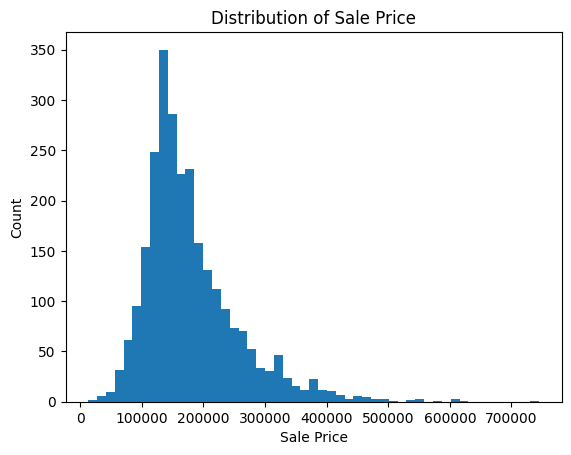

In [29]:
n = int(2637**(1/2))

plt.hist(df_clean['SalePrice'], bins=n)

plt.xlabel('Sale Price')
plt.ylabel('Count')
plt.title('Distribution of Sale Price')

plt.show()

###Boxplot

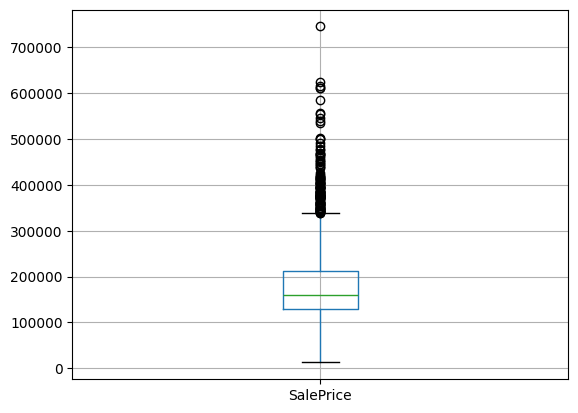

In [30]:
df_clean[['SalePrice']].boxplot()

plt.show()

###Correlation

In [32]:
corr = df_clean.corr(numeric_only=True)

corr['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.647223
Garage Area,0.633900
Total Bsmt SF,0.628669
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932


In [ ]:
cols = ['SalePrice'] + df_int.columns.tolist()
df_lr = df[cols]
df_lr

In [ ]:
corr_matrix = df_lr.corr().abs()
corr_matrix

In [ ]:
corr_matrix
sns.heatmap(
  corr_matrix,
  cmap='coolwarm',
  xticklabels = df_lr.columns,
  yticklabels = df_lr.columns,
  # annot=True,
  vmin = 0,
  vmax = 1,
  )

plt.title("Correlation Heatmap")
plt.savefig('corr.png')
plt.show()

##PH: Box-Cox Transformations

##PH: Feature Selection

##Train/Test Split

In [ ]:
#First we will break up our data into training and testing sets
X = df_lr.drop(columns=['SalePrice'])
y = df_lr['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=4)

In [ ]:
#Fit a linear model using Sklearn
model = LinearRegression()
myfit = model.fit(X_train, y_train)

(myfit.intercept_, myfit.coef_)

In [ ]:
#See how well our model performs on our test data
y_pred = myfit.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='red')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')

In [ ]:
#Calculate root mean squared error on test data
rmse = mean_squared_error(y_test, y_pred)**0.5
print(f"RMSE: {rmse}")

In [ ]:
#Use cross validation to assess model performance
results = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

##PH: Feature Scaling

##Regression

###Linear Regression

###Ridge Regression

###Lasso Regression

##PH: RMSPE Comparison

##PH: Feature Reduction

##PH: Interpolation vs Extrapolation Discussion

### Residual Analysis

In [ ]:
#QQ Plot - Residuals are normally distributed
res = y_test - y_pred
sm.qqplot(res, fit=True, line="45");

In [ ]:
#Residuals vs Fitted (Predicted) Values - Constant variance
plt.figure(figsize = (10,6))
plt.scatter(y_pred, res)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.hlines(0, min(y_pred), max(y_pred), colors = 'red', linestyles = 'dashed')

In [ ]:
#Residuals vs Time - indepedence
plt.figure(figsize = (10,6))
plt.scatter(range(len(res)), res)
plt.plot(range(len(res)), res, 'b')
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.hlines(0, min(range(len(res))), max(range(len(res))), colors = 'red', linestyles = 'dashed')

##Data Visualization/Communication of Results